In [262]:
import pandas as pd
import seaborn as sns

In [263]:
df=pd.read_csv('Fraud Detection Dataset (3).csv')
df             

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


**Basic Steps**

In [264]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [265]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [266]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [268]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [269]:
df.shape

(51000, 12)

In [270]:
df.duplicated().sum()

np.int64(881)

In [271]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [272]:
df.drop(['Transaction_ID','User_ID'],axis=1,inplace=True) 
df

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...
50995,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


**Exploratory Data Analysis**

In [273]:
df['Fraudulent'].value_counts()
df['Fraudulent'].value_counts(normalize=True)

Fraudulent
0    0.950784
1    0.049216
Name: proportion, dtype: float64

<Axes: xlabel='Fraudulent', ylabel='count'>

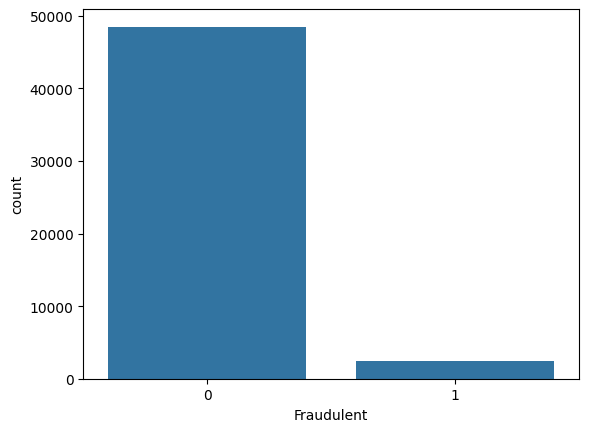

In [274]:
sns.countplot(x='Fraudulent', data=df)

In [275]:
num_cols = [
    'Transaction_Amount',
    'Time_of_Transaction',
    'Previous_Fraudulent_Transactions',
    'Account_Age',
    'Number_of_Transactions_Last_24H'
]
cat_cols = df.select_dtypes(include='object').columns

In [276]:
num_cols

['Transaction_Amount',
 'Time_of_Transaction',
 'Previous_Fraudulent_Transactions',
 'Account_Age',
 'Number_of_Transactions_Last_24H']

In [277]:
cat_cols

Index(['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method'], dtype='object')

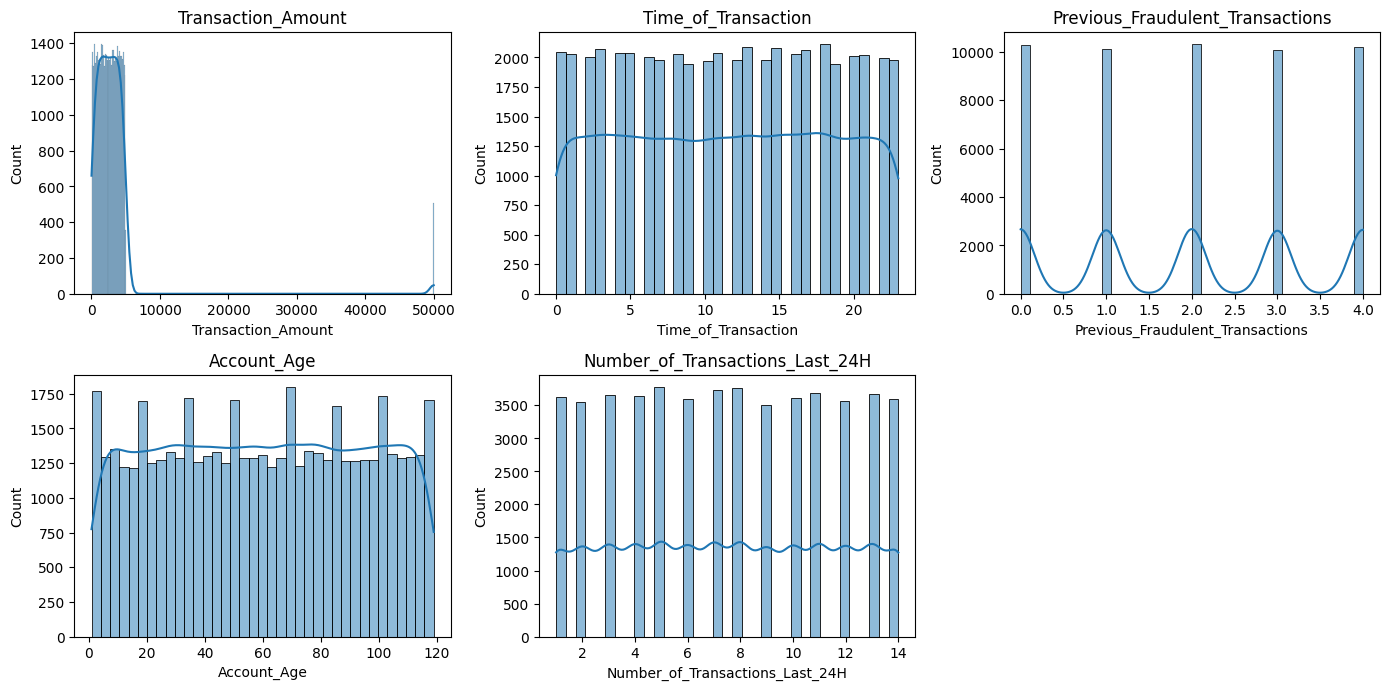

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

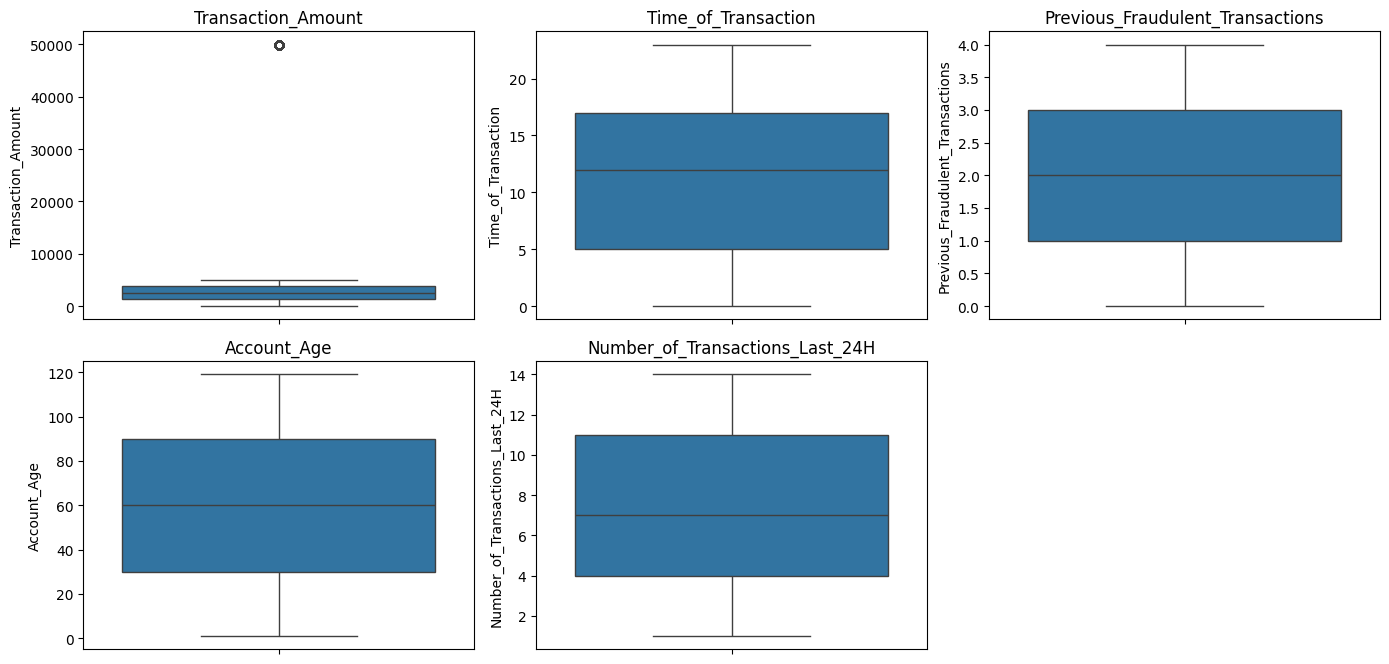

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(14,10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

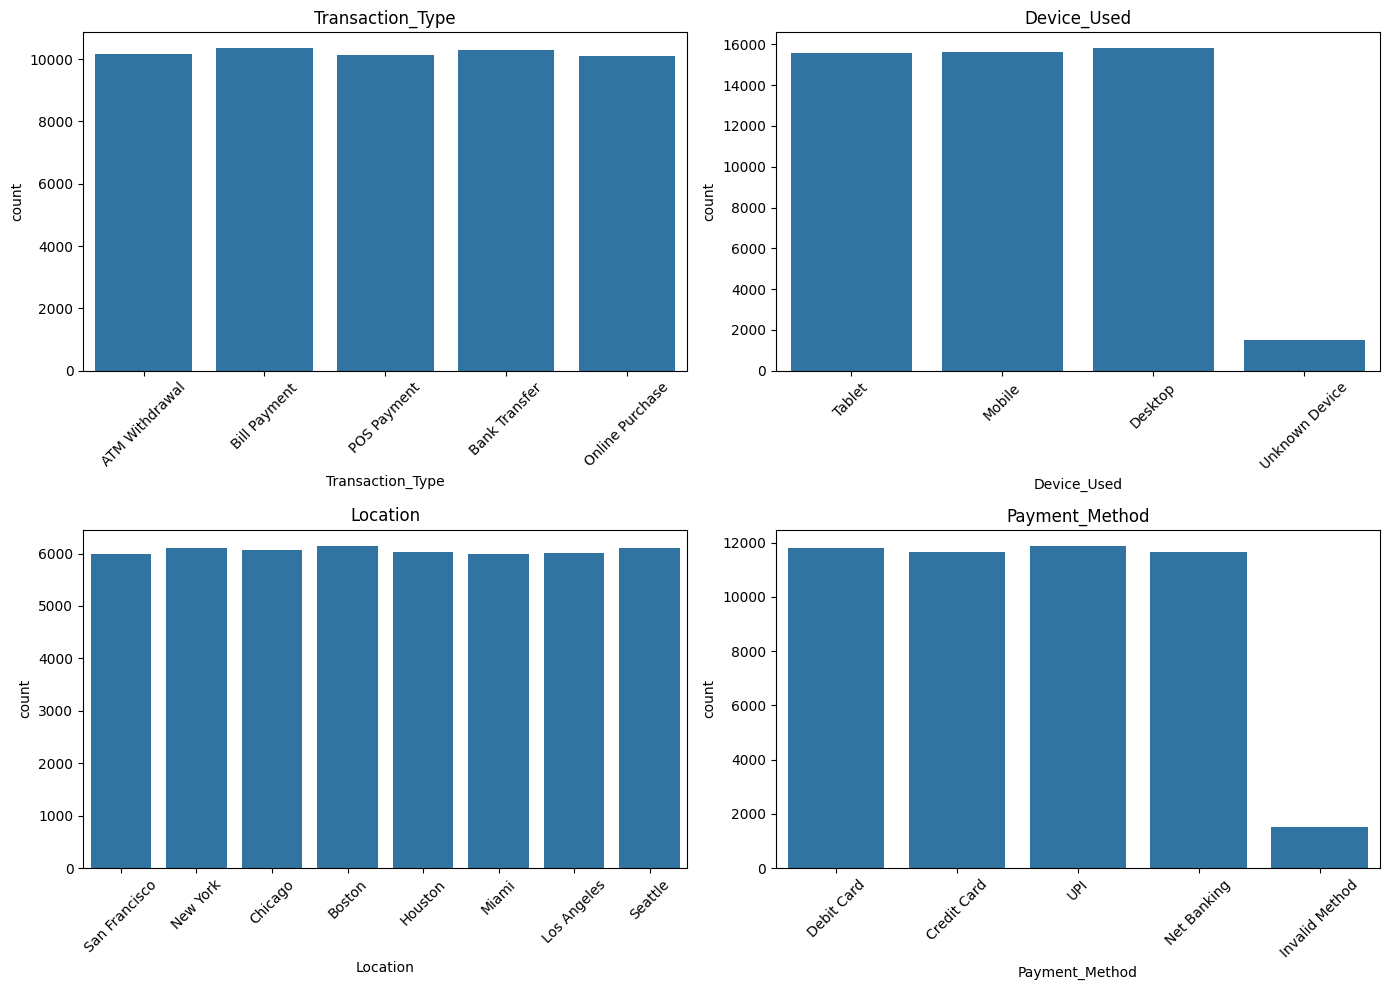

In [280]:
plt.figure(figsize=(14,10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

In [281]:
for col in num_cols:
    print(col)
    print("Skew:", df[col].skew())
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print()

Transaction_Amount
Skew: 8.454478956647055
Min: 5.03
Max: 49997.8

Time_of_Transaction
Skew: -0.0043662304642161885
Min: 0.0
Max: 23.0

Previous_Fraudulent_Transactions
Skew: 0.00444004490555927
Min: 0
Max: 4

Account_Age
Skew: -0.002970544587859595
Min: 1
Max: 119

Number_of_Transactions_Last_24H
Skew: 0.0052203920505880744
Min: 1
Max: 14



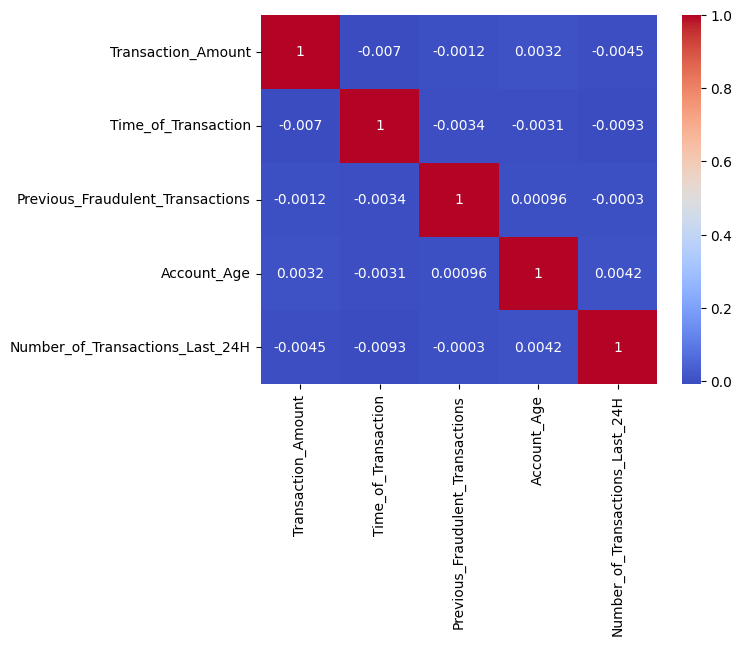

In [282]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

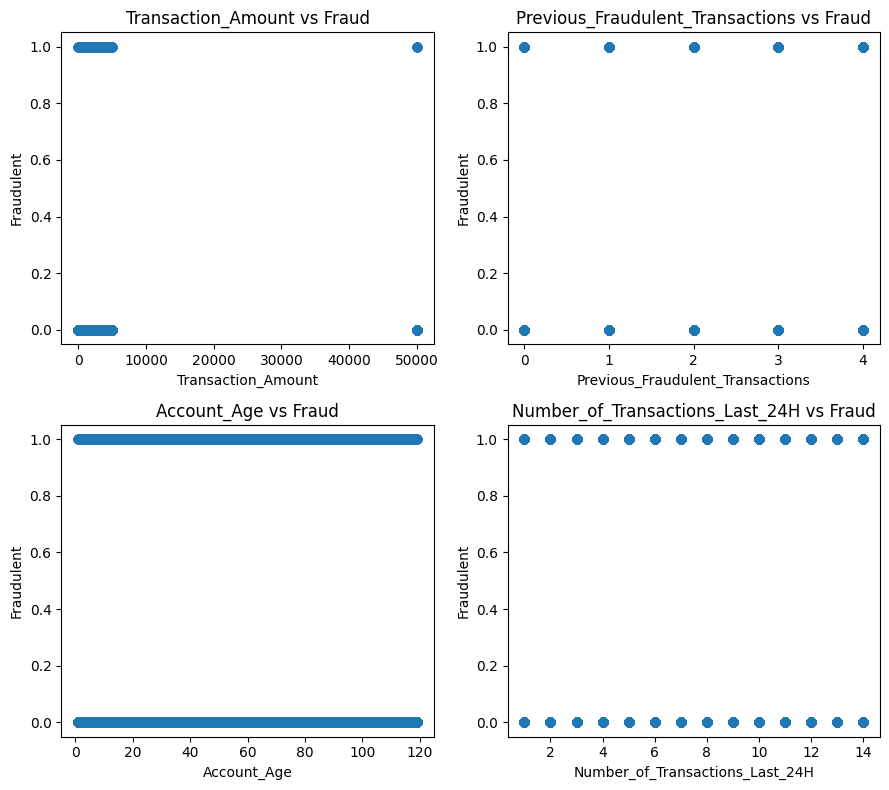

In [283]:
num_cols = [
    'Transaction_Amount',
    'Previous_Fraudulent_Transactions',
    'Account_Age',
    'Number_of_Transactions_Last_24H'
]

target = 'Fraudulent'

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df[target])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)
    axes[i].set_title(f"{col} vs Fraud")

plt.tight_layout()
plt.show()

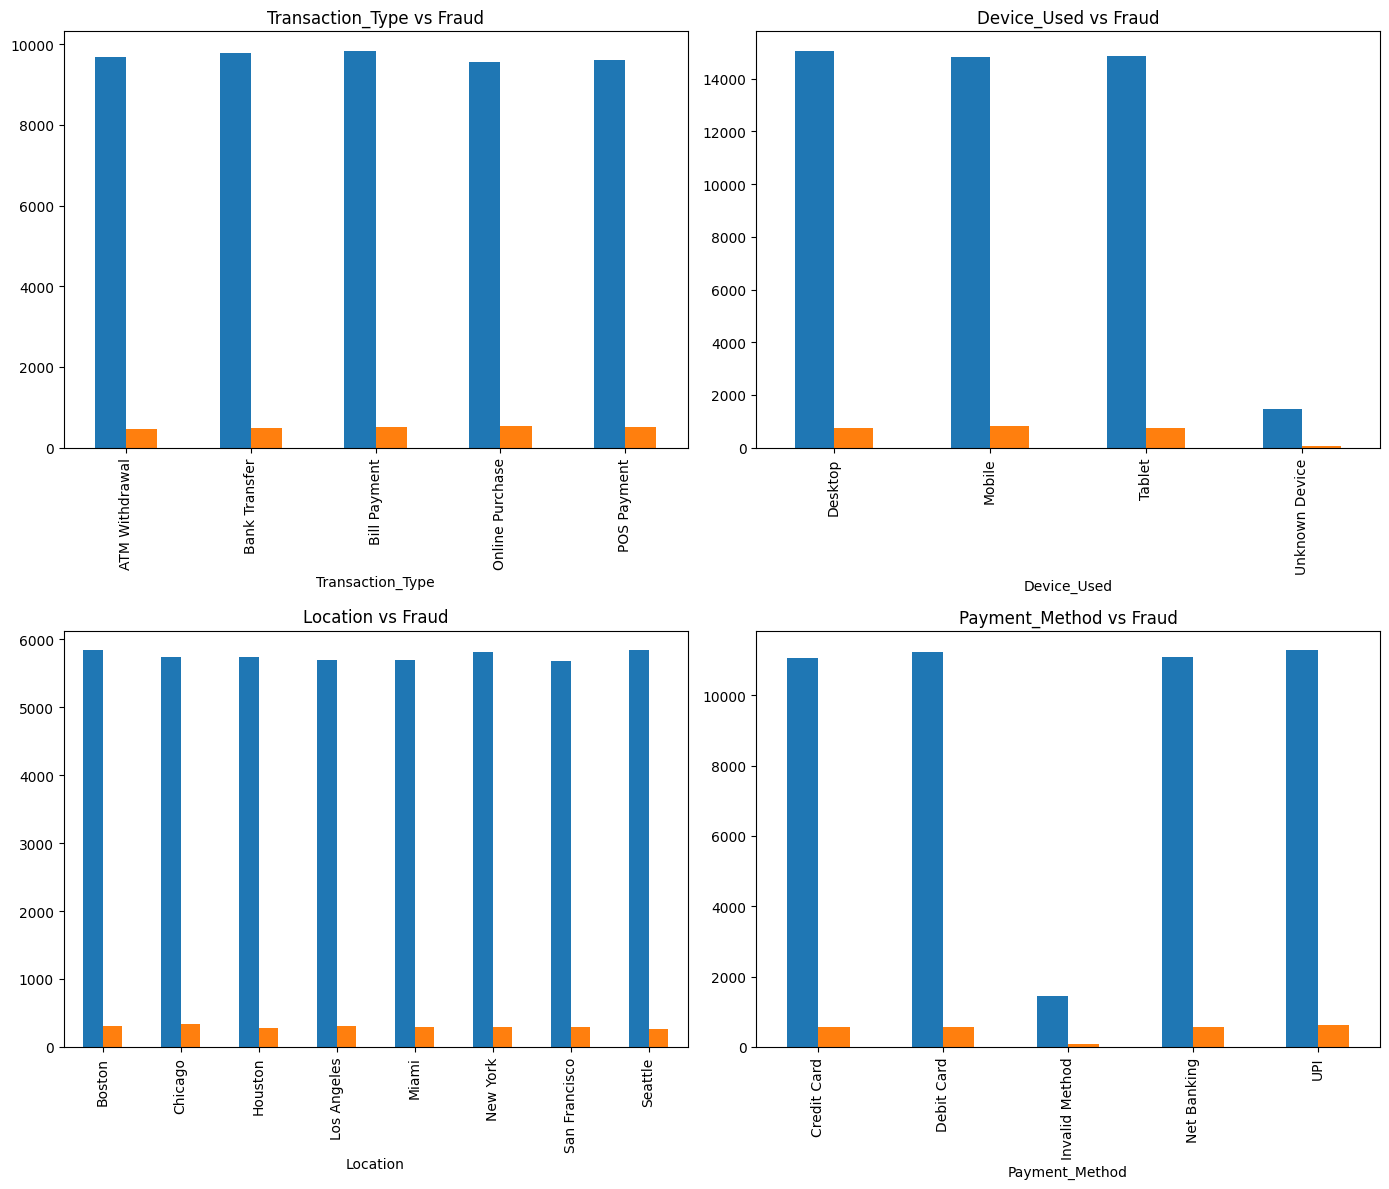

In [284]:
ig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['Fraudulent']).plot(
        kind='bar', ax=axes[i], legend=False
    )
    axes[i].set_title(f"{col} vs Fraud")

plt.tight_layout()
plt.show()

In [285]:
for col in cat_cols:
    print("\n", "="*50)
    print(f"Percentage Cross-tab: {col}")
    print(pd.crosstab(df[col], df['Fraudulent'], normalize='index') * 100)


Percentage Cross-tab: Transaction_Type
Fraudulent                0         1
Transaction_Type                     
ATM Withdrawal    95.346320  4.653680
Bank Transfer     95.192682  4.807318
Bill Payment      95.048356  4.951644
Online Purchase   94.808797  5.191203
POS Payment       94.993087  5.006913

Percentage Cross-tab: Device_Used
Fraudulent              0         1
Device_Used                        
Desktop         95.264324  4.735676
Mobile          94.837966  5.162034
Tablet          95.323326  4.676674
Unknown Device  95.098039  4.901961

Percentage Cross-tab: Location
Fraudulent             0         1
Location                          
Boston         94.958530  5.041470
Chicago        94.498435  5.501565
Houston        95.324159  4.675841
Los Angeles    94.843646  5.156354
Miami          95.025872  4.974128
New York       95.253682  4.746318
San Francisco  95.037594  4.962406
Seattle        95.642202  4.357798

Percentage Cross-tab: Payment_Method
Fraudulent             

**Null Value Handling**

In [286]:
df.isnull().sum()

Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [287]:
df['Transaction_Amount']= df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df["Time_of_Transaction"]=df["Time_of_Transaction"].fillna(df["Time_of_Transaction"].mean())
df["Device_Used"]=df["Device_Used"].fillna(df["Device_Used"].mode()[0])
df["Location"]=df["Location"].fillna(df["Location"].mode()[0])
df["Payment_Method"]=df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

In [288]:
df.isnull().sum()

Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

**removing duplicates**

In [289]:
df=df.drop_duplicates()

In [290]:
import numpy as np
Q1 = np.percentile(df['Transaction_Amount'], 25, method='midpoint')
Q2 = np.percentile(df['Transaction_Amount'], 50, method='midpoint')
Q3 = np.percentile(df['Transaction_Amount'], 75, method='midpoint')
print('Q1 is:',Q1)
print('Q2 is:',Q2)
print('Q3 is:',Q3)

Q1 is: 1333.37
Q2 is: 2524.1000000000004
Q3 is: 3721.755


In [291]:
IQR=Q3-Q1
print(IQR)

2388.385


In [292]:
low_lim=Q1-1.5*IQR
up_lim=Q3+1.5*IQR

print('lower value:',low_lim)
print('upper value:',up_lim)

lower value: -2249.2075000000004
upper value: 7304.3325


In [293]:
outliers=[]
for x in df['Transaction_Amount']:
    if((x<low_lim)or(x>up_lim)):
        outliers.append(x)

print(outliers)

[49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 49997.8, 

In [294]:
df.loc[(df['Transaction_Amount']>=up_lim),'Transaction_Amount']=up_lim

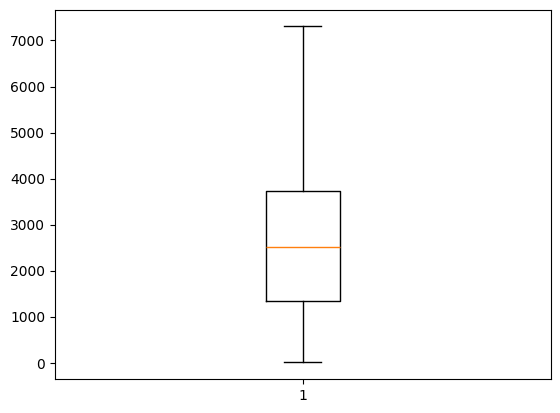

In [295]:
plt.boxplot(df['Transaction_Amount'])
plt.show()

In [296]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [297]:
import warnings
warnings.filterwarnings('ignore')

In [298]:
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()
le4=LabelEncoder()
df['Transaction_Type']=le1.fit_transform(df['Transaction_Type'])
df['Device_Used']=le2.fit_transform(df['Device_Used'])
df['Location']=le3.fit_transform(df['Location'])
df['Payment_Method']=le4.fit_transform(df['Payment_Method'])

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50119 entries, 0 to 50999
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_Amount                50119 non-null  float64
 1   Transaction_Type                  50119 non-null  int64  
 2   Time_of_Transaction               50119 non-null  float64
 3   Device_Used                       50119 non-null  int64  
 4   Location                          50119 non-null  int64  
 5   Previous_Fraudulent_Transactions  50119 non-null  int64  
 6   Account_Age                       50119 non-null  int64  
 7   Number_of_Transactions_Last_24H   50119 non-null  int64  
 8   Payment_Method                    50119 non-null  int64  
 9   Fraudulent                        50119 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 4.2 MB


In [300]:
#model

In [339]:
x=df.drop('Fraudulent',axis=1)
y=df['Fraudulent']

In [340]:
x

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method
0,1292.76,0,16.0000,2,6,0,119,13,1
1,1554.58,0,13.0000,1,5,4,79,3,0
2,2395.02,0,11.4884,1,0,3,115,9,4
3,100.10,2,15.0000,0,1,4,3,4,4
4,1490.50,4,19.0000,1,6,2,57,7,0
...,...,...,...,...,...,...,...,...,...
50964,4187.49,1,4.0000,1,1,2,67,13,4
50975,1826.49,4,10.0000,0,2,1,91,4,3
50985,544.53,1,14.0000,3,1,4,59,12,1
50997,2204.43,4,18.0000,1,6,3,73,5,0


In [341]:
y

0        0
1        0
2        0
3        0
4        0
        ..
50964    0
50975    0
50985    0
50997    0
50999    0
Name: Fraudulent, Length: 50119, dtype: int64

In [342]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [343]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [344]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaled_x_train=scaler.fit_transform(x_train)
scaled_x_test=scaler.transform(x_test)

**Logicaistic Regression**

In [345]:
from sklearn.linear_model import LogisticRegression

LR=LogisticRegression()
LR.fit(scaled_x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [346]:
y_pred_test_LR=LR.predict(scaled_x_test)

In [347]:
Test_score_LR=accuracy_score(y_test,y_pred_test_LR)
print('Test_score:',Test_score_LR)

Test_score: 0.9510175578611333


In [348]:
y_pred_train_LR=LR.predict(scaled_x_train)
y_pred_train_LR

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [349]:
Train_score=accuracy_score(y_pred_train_LR,y_train)
print('Train_score:',Train_score)

Train_score: 0.9507170470133434


In [350]:
cr=classification_report(y_test,y_pred_test_LR)
print('Classification Report:')
print(cr)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



In [351]:
cm=confusion_matrix(y_test,y_pred_test_LR)
print('Confusion Matrix:')
cm

Confusion Matrix:


array([[9533,    0],
       [ 491,    0]])

**KNeighborsClassifier**

In [352]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(scaled_x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [353]:
knn.score(scaled_x_test,y_test)

0.9510175578611333

In [354]:
y_pred_train_knn= knn.predict(scaled_x_train)
y_pred_train_knn 

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [355]:
score_train_knn=accuracy_score(y_pred_train_knn,y_train)
score_train_knn

0.9507170470133434

In [356]:
y_pred_test_knn=knn.predict(scaled_x_test)
y_pred_test_knn

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [357]:
knn_test_score=accuracy_score(y_test,y_pred_test_knn)
print('Test Score:',knn_test_score)

Test Score: 0.9510175578611333


In [358]:
cr=classification_report(y_test,y_pred_test_knn)
print('Classification Report:')
print(cr)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



In [359]:
cm=confusion_matrix(y_test,y_pred_test_knn)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[9533    0]
 [ 491    0]]


**Support Vector Classification**

**Kernel=Linera**

In [360]:
from sklearn.svm import SVC

In [361]:
from sklearn.metrics import accuracy_score

In [362]:
svc=SVC(kernel='linear')
svc.fit(scaled_x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [363]:
y_pred_train_svc=svc.predict(scaled_x_train)
y_pred_train_svc

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [364]:
train_score_svc=accuracy_score(y_train,y_pred_train_svc)
print('train score of Kernel-Linear:')
train_score_svc

train score of Kernel-Linear:


0.9507170470133434

In [365]:
y_pred_test_svc=svc.predict(scaled_x_test)
y_pred_test_svc

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [366]:
test_score_svc=accuracy_score(y_test,y_pred_test_svc)
test_score_svc

0.9510175578611333

**kernel=rbf**

In [367]:
svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(scaled_x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [368]:
y_pred_train_rbf = svc_rbf.predict(scaled_x_train)
y_pred_train_rbf

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [369]:
y_pred_test_rbf = svc_rbf.predict(scaled_x_test)
y_pred_test_rbf

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [370]:
train_accuracy_rbf=accuracy_score(y_train, y_pred_train_rbf)
train_accuracy_rbf

0.9507170470133434

In [371]:
test_accuray_rbf=accuracy_score(y_test, y_pred_test_rbf)
test_accuray_rbf

0.9510175578611333

In [372]:
print(classification_report(y_test, y_pred_test_rbf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



**sigmoid**

In [373]:
svc_sig=SVC(kernel='sigmoid')
svc_sig.fit(scaled_x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [374]:
y_pred_train_sig = svc_sig.predict(scaled_x_train)
y_pred_train_sig

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [375]:
y_pred_test_sig = svc_sig.predict(scaled_x_test)
y_pred_test_sig

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [376]:
train_accuracy_sig=accuracy_score(y_train, y_pred_train_sig)
train_accuracy_sig

0.908841501434094

In [377]:
test_accuray_sig=accuracy_score(y_test, y_pred_test_sig)
test_accuray_sig

0.9112130885873903

In [378]:
print(classification_report(y_test, y_pred_test_rbf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



**poly**

In [379]:
svc_pol=SVC(kernel='poly')
svc_pol.fit(scaled_x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [380]:
y_pred_train_pol = svc_pol.predict(scaled_x_train)
y_pred_train_pol

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [381]:
y_pred_test_pol = svc_pol.predict(scaled_x_test)
y_pred_test_pol

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [382]:
train_accuracy_pol=accuracy_score(y_train, y_pred_train_pol)
train_accuracy_pol

0.9507170470133434

In [383]:
test_accuray_pol=accuracy_score(y_test, y_pred_test_pol)
test_accuray_pol

0.9510175578611333

**DecisionTreeClassifier**

In [384]:
from sklearn.tree import DecisionTreeClassifier

In [385]:
DC=DecisionTreeClassifier()

In [386]:
DC.fit(scaled_x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [387]:
y_pred_test_DC=DC.predict(scaled_x_test)
y_pred_test_DC

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [388]:
y_pred_train_DC=DC.predict(scaled_x_train)
y_pred_train_DC

array([1, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [389]:
test_score_DC=accuracy_score(y_test,y_pred_test_DC)
test_score_DC

0.8878691141260974

In [390]:
train_score_DC=accuracy_score(y_train,y_pred_train_DC)
train_score_DC

1.0

**Random Forest**

In [391]:
from sklearn.ensemble import RandomForestClassifier

In [392]:
RC=RandomForestClassifier()
RC.fit(scaled_x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [393]:
y_pred_test_RC=RC.predict(scaled_x_test)
y_pred_train_RC=RC.predict(scaled_x_train)

In [394]:
train_score_RC=accuracy_score(y_pred_train_RC,y_train)
train_score_RC

0.9999002369372739

In [395]:
test_score_RC=accuracy_score(y_pred_test_RC,y_test)
test_score_RC

0.9510175578611333

In [396]:
print(classification_report(y_test,y_pred_test_RC))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



In [397]:
confusion_matrix(y_test,y_pred_test_RC)

array([[9533,    0],
       [ 491,    0]])

**NaiveBaseAlgorithm**

In [398]:
from sklearn.naive_bayes import GaussianNB

In [399]:
NB = GaussianNB()
NB.fit(scaled_x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [400]:
y_pred_train_NB = NB.predict(scaled_x_train)
y_pred_test_NB = NB.predict(scaled_x_test)

In [401]:
train_score_NB = accuracy_score(y_train, y_pred_train_NB)
train_score_NB

0.9507170470133434

In [402]:
test_score_NB = accuracy_score(y_test, y_pred_test_NB)
test_score_NB

0.9510175578611333

In [403]:
cm_NB = confusion_matrix(y_test, y_pred_test_NB)
print("Confusion Matrix:\n", cm_NB)

Confusion Matrix:
 [[9533    0]
 [ 491    0]]


In [404]:
cr_NB = classification_report(y_test, y_pred_test_NB)
print("Classification Report:\n", cr_NB)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



**GradientBoostingClassifier**

In [405]:
from sklearn.ensemble import GradientBoostingClassifier

In [406]:
gbc=GradientBoostingClassifier(n_estimators=600,learning_rate=0.05,random_state=100)
gbc.fit(scaled_x_train,y_train) 

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",600
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [407]:
y_pred_train_gbc = gbc.predict(scaled_x_train)
y_pred_train_gbc

array([0, 0, 0, ..., 0, 0, 0], shape=(40095,))

In [408]:
train_acc_gb = accuracy_score(y_train, y_pred_train_gbc)
train_acc_gb

0.9512408030926549

In [409]:
y_pred_test_gbc=gbc.predict(scaled_x_test)
y_pred_test_gbc

array([0, 0, 0, ..., 0, 0, 0], shape=(10024,))

In [410]:
test_acc_gb = accuracy_score(y_test, y_pred_test_gbc)
test_acc_gb

0.9508180367118915

In [411]:
cm_gb = confusion_matrix(y_test, y_pred_test_gbc)
print("Confusion Matrix:\n", cm_gb)

Confusion Matrix:
 [[9531    2]
 [ 491    0]]


In [412]:
cr_gb = classification_report(y_test, y_pred_test_gbc)
print("Classification Report:\n", cr_gb)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



**XGBClassifier**

In [413]:
from xgboost import XGBClassifier

In [414]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [415]:
xgb.fit(scaled_x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [416]:
y_pred_train_xgb = xgb.predict(scaled_x_train)
y_pred_test_xgb = xgb.predict(scaled_x_test)

In [417]:
train_acc_xgb = accuracy_score(y_train, y_pred_train_xgb)
train_acc_xgb

0.95149021074947

In [418]:
test_acc_xgb = accuracy_score(y_test, y_pred_test_xgb)
test_acc_xgb

0.9509177972865124

In [419]:
cm_xgb = confusion_matrix(y_test, y_pred_test_xgb)
print("Confusion Matrix:\n", cm_xgb)

Confusion Matrix:
 [[9532    1]
 [ 491    0]]


In [420]:
cr_xgb = classification_report(y_test, y_pred_test_xgb)
print("Classification Report:\n", cr_xgb)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



**AdaBoostClassifier**

In [421]:
from sklearn.ensemble import AdaBoostClassifier

In [422]:
base_model = DecisionTreeClassifier(max_depth=1)

In [423]:
ada = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)


In [424]:
ada.fit(scaled_x_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [425]:
y_pred_train_ada = ada.predict(scaled_x_train)
y_pred_test_ada = ada.predict(scaled_x_test)

In [426]:
train_acc_ada = accuracy_score(y_train, y_pred_train_ada)
train_acc_ada

0.9507170470133434

In [427]:
test_acc_ada = accuracy_score(y_test, y_pred_test_ada)
test_acc_ada

0.9510175578611333

In [428]:
cm_ada = confusion_matrix(y_test, y_pred_test_ada)
print("Confusion Matrix:\n", cm_ada)

Confusion Matrix:
 [[9533    0]
 [ 491    0]]


In [429]:
cr_ada = classification_report(y_test, y_pred_test_ada)
print("Classification Report:\n", cr_ada)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      9533
           1       0.00      0.00      0.00       491

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024



In [434]:
models = {
    "Logistic Regression": LR,
    "KNN": knn,
    "Decision Tree": DC,
    "Random Forest": RC,
    "Naive Bayes": NB,
    "SVC": svc,
    "Gradient Boosting": gbc,
    "XGBoost": xgb,
    "AdaBoost": ada
}

In [435]:
initial_model_prediction = []

In [436]:
for name, model in models.items():
    
    train_acc = model.score(scaled_x_train, y_train)
    test_acc = model.score(scaled_x_test, y_test)
    
    initial_model_prediction.append({
        "Model Name": name,
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4)
    })

In [437]:
initial_model = pd.DataFrame(initial_model_prediction)

In [438]:
initial_model = initial_model.sort_values(by="Testing Accuracy", ascending=False)

In [439]:
initial_model= initial_model.reset_index(drop=True)
initial_model

,Model Name,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.9507,0.9510
1,KNN,0.9507,0.9510
2,Random Forest,0.9999,0.9510
3,Naive Bayes,0.9507,0.9510
4,SVC,0.9507,0.9510
5,AdaBoost,0.9507,0.9510
6,XGBoost,0.9515,0.9509
7,Gradient Boosting,0.9512,0.9508
8,Decision Tree,1.0000,0.8879


**Balancing Data**

In [ ]:
df['Fraudulent'].value_counts()

In [ ]:
pip install -U scikit-learn imbalanced-learn

In [133]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_res,y_res=smote.fit_resample(x,y)

In [134]:
y_res.value_counts()

Fraudulent
0    47652
1    47652
Name: count, dtype: int64

**Train Test Split After Balancing**

In [135]:
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.3,random_state=42)

**HyperParameter Tuning**

In [136]:
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold

**LogisticRegression balanced**

In [137]:
LR = LogisticRegression(class_weight='balanced')

params_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.5, 1, 10],
    'solver': ['liblinear','sag'],
    'max_iter': [1000, 2000]
}

In [138]:
gscv_lr=GridSearchCV(LR,params_lr,scoring="f1",cv=StratifiedKFold(n_splits=5),n_jobs=1,verbose=2)
gscv_lr.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END .C=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   1.1s
[CV] END .C=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.9s
[CV] END .C=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.9s
[CV] END .C=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   1.0s
[CV] END .C=0.5, max_iter=1000, penalty=l1, solver=liblinear; total time=   0.8s
[CV] END .......C=0.5, max_iter=1000, penalty=l1, solver=sag; total time=   0.0s
[CV] END .......C=0.5, max_iter=1000, penalty=l1, solver=sag; total time=   0.0s
[CV] END .......C=0.5, max_iter=1000, penalty=l1, solver=sag; total time=   0.0s
[CV] END .......C=0.5, max_iter=1000, penalty=l1, solver=sag; total time=   0.0s
[CV] END .......C=0.5, max_iter=1000, penalty=l1, solver=sag; total time=   0.0s
[CV] END .C=0.5, max_iter=1000, penalty=l2, solver=liblinear; total time=   0.4s
[CV] END .C=0.5, max_iter=1000, penalty=l2, sol

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.5, 1, ...], 'max_iter': [1000, 2000], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'sag']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [139]:
gscv_lr.best_score_

np.float64(0.6429712499718814)

In [140]:
gscv_lr.best_params_

{'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}

In [141]:
lr=LogisticRegression(class_weight='balanced',C=10, max_iter= 1000, penalty= 'l1', solver= 'liblinear')
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [142]:
y_pred_train_lr=lr.predict(x_train)

In [143]:
y_pred_test_lr=lr.predict(x_test)

In [144]:
Train_score_lr=accuracy_score(y_pred_train_lr,y_train)
print('Train_score:',Train_score_lr)

Train_score: 0.6353579565895191


In [145]:
Test_score_lr=accuracy_score(y_test,y_pred_test_lr)
print('Test_score:',Test_score_lr)

Test_score: 0.6337087297146055


In [146]:
cr_lr=classification_report(y_test,y_pred_test_lr)
print('Classification Report:')
print(cr_lr)

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.61      0.63     14387
           1       0.63      0.65      0.64     14205

    accuracy                           0.63     28592
   macro avg       0.63      0.63      0.63     28592
weighted avg       0.63      0.63      0.63     28592



In [147]:
cm_lr=confusion_matrix(y_test,y_pred_test_lr)
print('Confusion Matrix:')
cm_lr

Confusion Matrix:


array([[8818, 5569],
       [4904, 9301]])

**KNN BALANCED**

In [148]:
KNN = KNeighborsClassifier()

params_knn = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

In [ ]:
gscv_knn = GridSearchCV(KNN, params_knn, scoring="f1", cv=StratifiedKFold(n_splits=5), n_jobs=-1)
gscv_knn.fit(x_train, y_train)

In [ ]:
gscv_knn.best_score_

In [ ]:
gscv_knn.best_params_

In [ ]:
knn_C = gscv_knn.best_estimator_
knn_C.fit(x_train, y_train)

In [ ]:
y_pred_train_KNN = knn_C.predict(x_train)
y_pred_train_KNN

In [ ]:
y_pred_test_KNN = knn_C.predict(x_test)
y_pred_test_KNN

In [ ]:
Train_score_KNN=accuracy_score(y_pred_train_KNN,y_train)
print('Train_score:',Train_score_KNN)

In [ ]:
Test_score_KNN=accuracy_score(y_test,y_pred_test_KNN)
print('Test_score:',Test_score_KNN)

In [ ]:
cr_KNN=classification_report(y_test,y_pred_test_KNN)
print('Classification Report:')
print(cr_KNN)

In [ ]:
cm_KNN=confusion_matrix(y_test,y_pred_test_KNN)
print('Confusion Matrix:')
cm_KNN

**SVM BALANCED**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


In [237]:
svc = LinearSVC(class_weight='balanced')

params_svc = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000, 2000]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
random_svc = RandomizedSearchCV(
    svc,
    params_svc,
    n_iter=4,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=42
)

random_svc.fit(x_train, y_train)

In [ ]:
print("Best Score:", random_svc.best_score_)
print("Best Params:", random_svc.best_params_)

best_svc = random_svc.best_estimator_

In [ ]:
best_svc.fit(x_train, y_train)

In [ ]:
y_train_pred_SVC = best_svc.predict(x_train)
y_test_pred_SVC = best_svc.predict(x_test)

In [ ]:
train_score_SVC = accuracy_score(y_train, y_train_pred_SVC)
test_score_SVC = accuracy_score(y_test, y_test_pred_SVC)

In [ ]:
print("Train Score:", train_score_SVC)
print("Test Score:", test_score_SVC)

In [ ]:
cr_SVM=classification_report(y_test,y_test_pred_SVC)
print('Classification Report:')
print(cr_SVM)

In [ ]:
cm_SVM=confusion_matrix(y_test,y_test_pred_SVC)
print('Confusion Matrix:')
cm_SVM

**DecisionTreeClassifier Balanced**

In [234]:
DT = DecisionTreeClassifier(random_state=42)

params_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],
}

In [235]:
gscv_dt = GridSearchCV(
    DT,
    params_dt,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5),
    n_jobs=-1,
    verbose=2
)
gscv_dt.fit(x_train, y_train)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [238]:
gscv_dt.best_score_

np.float64(0.9179383225120297)

In [239]:
gscv_dt.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [173]:
gscv_DT = gscv_dt.best_estimator_
gscv_DT.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [174]:
y_pred_train_DT = gscv_DT.predict(x_train)
y_pred_train_DT

array([0, 1, 0, ..., 1, 0, 0], shape=(66712,))

In [175]:
y_pred_test_DT = gscv_DT.predict(x_test)
y_pred_test_DT

array([0, 1, 0, ..., 0, 0, 1], shape=(28592,))

In [176]:
Train_score_DT=accuracy_score(y_pred_train_DT,y_train)
print('Train_score:',Train_score_DT)

Train_score: 0.9731982252068594


In [177]:
Test_score_DT=accuracy_score(y_test,y_pred_test_DT)
print('Test_score:',Test_score_DT)

Test_score: 0.924664241745943


In [178]:
cr_DT=classification_report(y_test,y_pred_test_DT)
print('Classification Report:')
print(cr_DT)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14387
           1       0.92      0.92      0.92     14205

    accuracy                           0.92     28592
   macro avg       0.92      0.92      0.92     28592
weighted avg       0.92      0.92      0.92     28592



In [179]:
cm_DT=confusion_matrix(y_test,y_pred_test_DT)
print('Confusion Matrix:')
cm_DT

Confusion Matrix:


array([[13322,  1065],
       [ 1089, 13116]])

**random forest**

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV

RF = RandomForestClassifier(random_state=42,n_jobs=-1)

params_rf = {
    'n_estimators': [50, 80],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

In [181]:
random_rf = RandomizedSearchCV(
    RF,
    param_distributions=params_rf,
    n_iter=6,                 # only 6 combinations tested
    scoring='f1',
    cv= StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [182]:
random_rf.fit(x_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt'], 'min_samples_split': [2, 5], 'n_estimators': [50, 80]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv

In [183]:
print("Best Params:", random_rf.best_params_)
print("Best Score:", random_rf.best_score_)

Best Params: {'n_estimators': 80, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
Best Score: 0.8852491099907697


In [184]:
R_RF = random_rf.best_estimator_
R_RF.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [185]:
y_pred_train_RF = gscv_DT.predict(x_train)
y_pred_train_RF

array([0, 1, 0, ..., 1, 0, 0], shape=(66712,))

In [186]:
y_pred_test_RF = gscv_DT.predict(x_test)
y_pred_test_RF

array([0, 1, 0, ..., 0, 0, 1], shape=(28592,))

In [187]:
Train_score_RF=accuracy_score(y_pred_train_RF,y_train)
print('Train_score:',Train_score_RF)

Train_score: 0.9731982252068594


In [188]:
Test_score_RF=accuracy_score(y_test,y_pred_test_RF)
print('Test_score:',Test_score_RF)

Test_score: 0.924664241745943


In [189]:
cr_RF=classification_report(y_test,y_pred_test_RF)
print('Classification Report:')
print(cr_RF)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93     14387
           1       0.92      0.92      0.92     14205

    accuracy                           0.92     28592
   macro avg       0.92      0.92      0.92     28592
weighted avg       0.92      0.92      0.92     28592



In [190]:
cm_RF=confusion_matrix(y_test,y_pred_test_RF)
print('Confusion Matrix:')
cm_RF

Confusion Matrix:


array([[13322,  1065],
       [ 1089, 13116]])

**NaiveBaseAlgorithm Balanced**

In [191]:
NB = GaussianNB()

params_nb = {
    'var_smoothing':[1e-9,1e-8,1e-7]
}

gscv_nb = GridSearchCV(NB, params_nb, scoring="f1", cv=StratifiedKFold(n_splits=5))
gscv_nb.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-09, 1e-08, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [192]:
gscv_nb.best_score_

np.float64(0.7342379851988923)

In [193]:
gscv_nb.best_params_

{'var_smoothing': 1e-07}

In [194]:
gscv_nb = gscv_nb.best_estimator_
gscv_nb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-07


In [195]:
y_pred_train_nb = gscv_nb.predict(x_train)
y_pred_train_nb

array([0, 0, 1, ..., 0, 1, 1], shape=(66712,))

In [196]:
y_pred_test_nb = gscv_nb.predict(x_test)
y_pred_test_nb

array([0, 1, 1, ..., 0, 1, 0], shape=(28592,))

In [197]:
Train_score_nb=accuracy_score(y_pred_train_nb,y_train)
print('Train_score:',Train_score_nb)

Train_score: 0.7113862573450054


In [198]:
Test_score_nb=accuracy_score(y_test,y_pred_test_nb)
print('Test_score:',Test_score_nb)

Test_score: 0.7080302182428652


In [199]:
cr_nb=classification_report(y_test,y_pred_test_nb)
print('Classification Report:')
print(cr_nb)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68     14387
           1       0.67      0.80      0.73     14205

    accuracy                           0.71     28592
   macro avg       0.72      0.71      0.71     28592
weighted avg       0.72      0.71      0.71     28592



In [200]:
cm_nb=confusion_matrix(y_test,y_pred_test_nb)
print('Confusion Matrix:')
cm_nb

Confusion Matrix:


array([[ 8926,  5461],
       [ 2887, 11318]])

**GradientBoostingClassifier Balancing**

In [201]:
from sklearn.ensemble import GradientBoostingClassifier

GB = GradientBoostingClassifier()

params_gb = {
    'n_estimators':[100,200],
    'learning_rate':[0.05,0.1],
    'max_depth':[3,5]
}

gscv_GB = GridSearchCV(GB, params_gb, scoring="f1", cv=3)
gscv_GB.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is 

In [202]:
gscv_GB.best_score_

np.float64(0.9522999769128875)

In [203]:
gscv_GB.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

In [204]:
gscv_GB = gscv_GB.best_estimator_
gscv_GB.fit(x_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [205]:
y_pred_train_GB = gscv_GB.predict(x_train)
y_pred_train_GB

array([0, 0, 0, ..., 1, 0, 0], shape=(66712,))

In [206]:
y_pred_test_GB = gscv_GB.predict(x_test)
y_pred_test_GB

array([0, 1, 0, ..., 1, 0, 1], shape=(28592,))

In [207]:
Train_score_GB=accuracy_score(y_pred_train_GB,y_train)
print('Train_score:',Train_score_GB)

Train_score: 0.9563047127952992


In [208]:
Test_score_GB=accuracy_score(y_test,y_pred_test_GB)
print('Test_score:',Test_score_GB)

Test_score: 0.9538332400671516


In [209]:
cr_GB=classification_report(y_test,y_pred_test_GB)
print('Classification Report:')
print(cr_GB)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     14387
           1       1.00      0.91      0.95     14205

    accuracy                           0.95     28592
   macro avg       0.96      0.95      0.95     28592
weighted avg       0.96      0.95      0.95     28592



In [210]:
cm_GB=confusion_matrix(y_test,y_pred_test_GB)
print('Confusion Matrix:')
cm_GB

Confusion Matrix:


array([[14359,    28],
       [ 1292, 12913]])

**XGBClassifier Balanced**

In [211]:
from xgboost import XGBClassifier

XGB = XGBClassifier(eval_metric='logloss')

params_xgb = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.05,0.1]
}

In [212]:
gscv_xgb = GridSearchCV(XGB, params_xgb, scoring="f1", cv=3)
gscv_xgb.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [213]:
gscv_xgb.best_score_

np.float64(0.9070821467897315)

In [214]:
gscv_xgb.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

In [215]:
gscv_XGB = gscv_xgb.best_estimator_
gscv_XGB.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [216]:
y_pred_train_XGB = gscv_xgb.predict(x_train)
y_pred_train_XGB

array([0, 0, 0, ..., 1, 0, 1], shape=(66712,))

In [217]:
y_pred_test_XGB = gscv_GB.predict(x_test)
y_pred_test_XGB

array([0, 1, 0, ..., 1, 0, 1], shape=(28592,))

In [218]:
Train_score_XGB=accuracy_score(y_pred_train_XGB,y_train)
print('Train_score:',Train_score_XGB)

Train_score: 0.9188301954670823


In [219]:
Test_score_XGB=accuracy_score(y_test,y_pred_test_XGB)
print('Test_score:',Test_score_XGB)

Test_score: 0.9538332400671516


In [220]:
cr_XGB=classification_report(y_test,y_pred_test_XGB)
print('Classification Report:')
print(cr_XGB)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     14387
           1       1.00      0.91      0.95     14205

    accuracy                           0.95     28592
   macro avg       0.96      0.95      0.95     28592
weighted avg       0.96      0.95      0.95     28592



In [221]:
cm_XGB=confusion_matrix(y_test,y_pred_test_XGB)
print('Confusion Matrix:')
cm_XGB

Confusion Matrix:


array([[14359,    28],
       [ 1292, 12913]])

**AdaBoostClassifier Balanced**

In [222]:
from sklearn.ensemble import AdaBoostClassifier

ADA = AdaBoostClassifier(random_state=42)

params_ada = {
    'n_estimators':[100,200],
    'learning_rate':[0.5,1.0]
}

In [223]:
gscv_ada = GridSearchCV(ADA, params_ada, scoring="f1", cv=3)
gscv_ada.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.5, 1.0], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [224]:
print('best_score:', gscv_ada.best_score_)
print('best_params:', gscv_ada.best_params_)

best_score: 0.7669384182115678
best_params: {'learning_rate': 1.0, 'n_estimators': 200}


In [225]:
gscv_ADA = gscv_ada.best_estimator_
gscv_ADA.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [226]:
y_pred_train_ADA = gscv_ADA.predict(x_train)
y_pred_train_ADA

array([0, 0, 1, ..., 1, 1, 1], shape=(66712,))

In [227]:
y_pred_test_ADA = gscv_ADA.predict(x_test)
y_pred_test_ADA

array([0, 1, 1, ..., 0, 1, 0], shape=(28592,))

In [228]:
Train_score_ADA=accuracy_score(y_pred_train_ADA,y_train)
print('Train_score:',Train_score_ADA)

Train_score: 0.7573749850101931


In [229]:
Test_score_ADA=accuracy_score(y_test,y_pred_test_ADA)
print('Test_score:',Test_score_ADA)

Test_score: 0.7586387800783436


In [230]:
cr_ADA=classification_report(y_test,y_pred_test_ADA)
print('Classification Report:')
print(cr_ADA)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75     14387
           1       0.74      0.79      0.77     14205

    accuracy                           0.76     28592
   macro avg       0.76      0.76      0.76     28592
weighted avg       0.76      0.76      0.76     28592



In [231]:
cm_ADA=confusion_matrix(y_test,y_pred_test_ADA)
print('Confusion Matrix:')
cm_ADA

Confusion Matrix:


array([[10428,  3959],
       [ 2942, 11263]])

In [232]:
model_collection = []

In [233]:
a = {
    'model': 'Logistic Regression',
    'best_score': gscv_lr.best_score_,
    'best_params': gscv_lr.best_params_
}
a = {
    'model': 'KNN',
    'best_score': gscv_knn.best_score_,
    'best_params': gscv_knn.best_params_
}

model_collection.append(a)

In [243]:
Tuned_models = {
    "Logistic Regression": lr,
    "KNN": knn_C,
    "Random Forest": R_RF,
    "SVC": best_svc,
    "Decision Tree": gscv_DT,
    "Naive Bayes": gscv_nb,
    "Gradient Boosting": gscv_GB,
    "XGBoost": gscv_XGB,
    "AdaBoost": gscv_ADA
}

In [244]:
results = []

In [245]:
for name, model in Tuned_models.items():
    
    train_score = model.score(x_train, y_train)
    test_score = model.score(x_test, y_test)
    
    results.append({
        "Model": name,
        "Training Score": round(train_score, 4),
        "Testing Score": round(test_score, 4)
    })


In [250]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="Testing Score", ascending=False)
print(df_results)

                 Model  Training Score  Testing Score
6    Gradient Boosting          0.9563         0.9538
4        Decision Tree          0.9732         0.9247
7              XGBoost          0.9188         0.9145
2        Random Forest          1.0000         0.9005
1                  KNN          1.0000         0.8542
8             AdaBoost          0.7574         0.7586
5          Naive Bayes          0.7114         0.7080
0  Logistic Regression          0.6354         0.6337
3                  SVC          0.6357         0.6337


In [252]:
df_results = df_results.reset_index(drop=True)
df_results.columns = ["Model Name", "Training Accuracy", "Testing Accuracy"]
df_results


,Model Name,Training Accuracy,Testing Accuracy
0,Gradient Boosting,0.9563,0.9538
1,Decision Tree,0.9732,0.9247
2,XGBoost,0.9188,0.9145
3,Random Forest,1.0000,0.9005
4,KNN,1.0000,0.8542
5,AdaBoost,0.7574,0.7586
6,Naive Bayes,0.7114,0.7080
7,Logistic Regression,0.6354,0.6337
8,SVC,0.6357,0.6337


In [5]:
models = ['Gradient Boosting','Decision Tree','XGBoost','Random Forest','KNN','AdaBoost','Naive Bayes','Logistic Regression','SVC']

# Accuracy scores on unbalanced data
accuracy_unbalanced = [0.9508 ,0.8879 ,0.9509 ,0.9510 ,0.9510 ,0.9510 ,0.9510 , 0.9510 ,0.9510]

# Accuracy scores on balanced data
accuracy_balanced = [0.9538 , 0.9247, 0.9145, 0.9005, 0.8542, 0.7586, 0.7080, 0.6337,0.6337]


In [7]:
import pandas as pd
results_df = pd.DataFrame({
    'Model': models,
    'Accuracy (Unbalanced)': accuracy_unbalanced,
    'Accuracy (Balanced)': accuracy_balanced
})

In [8]:
print(results_df)

                 Model  Accuracy (Unbalanced)  Accuracy (Balanced)
0    Gradient Boosting                 0.9508               0.9538
1        Decision Tree                 0.8879               0.9247
2              XGBoost                 0.9509               0.9145
3        Random Forest                 0.9510               0.9005
4                  KNN                 0.9510               0.8542
5             AdaBoost                 0.9510               0.7586
6          Naive Bayes                 0.9510               0.7080
7  Logistic Regression                 0.9510               0.6337
8                  SVC                 0.9510               0.6337


In [444]:
model=gscv_GB
model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [440]:
import joblib

In [ ]:
C:/Users/USER/Fraud Detection Dataset (3).pkl

In [442]:
joblib.dump(model,'C:/Users/USER/Fraud Detection Dataset (3).pkl')

['C:/Users/USER/Fraud Detection Dataset (3).pkl']

In [452]:
joblib.dump(le1,'C:/Users/USER/le1.pkl')
joblib.dump(le2,'C:/Users/USER/le2.pkl')
joblib.dump(le3,'C:/Users/USER/le3.pkl')
joblib.dump(le4,'C:/Users/USER/le4.pkl')
joblib.dump(scaler,'C:/Users/USER/scalerfraud.pkl')

['C:/Users/USER/scalerfraud.pkl']

In [447]:
df.head()

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,0,16.0000,2,6,0,119,13,1,0
1,1554.58,0,13.0000,1,5,4,79,3,0,0
2,2395.02,0,11.4884,1,0,3,115,9,4,0
3,100.10,2,15.0000,0,1,4,3,4,4,0
4,1490.50,4,19.0000,1,6,2,57,7,0,0
